# GLFTMM Result Curves

Use `sim/report.py` to discover result folders and plot the curve for every folder.

In [22]:
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

REPO_ROOT = Path("/home/kang/glftmm")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

report_tools = importlib.import_module("sim.report")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_rows", 200)

Edit the variables below when you want a different symbol, date range, folder keyword, or plotting density.

In [23]:
with open(REPO_ROOT / "config/config1.json", "r", encoding="utf-8") as fh:
    CONFIG = json.load(fh)

ROOT_DIR = Path(CONFIG["paths"]["output_dir"])
SYMBOL = CONFIG.get("symbols", ["BTCUSDT"])[0]

# Use None for the full available range. Date format can be YYYY-MM-DD or YYYYMMDD.
SRT = None
END = None
EXCLUDE_DATE = None

# Optional folder-path substring filter, for example "md1" or "pg10x50".
KEYWORD = None

# Larger EVERY is faster and lighter. Set lower for smoother intraday curves.
EVERY = 600

# Cap points sent to matplotlib per run after EVERY sampling. Use None to disable.
MAX_PLOT_POINTS = 50_000

# PNL_ONLY=True plots only total PnL curves. False plots price/inventory/PnL/volume panels.
PNL_ONLY = False
NORMALIZE = False

# Plot folders in batches so each chart remains readable.
BATCH_SIZE = 6
NUM_WORKERS = 4

# Set to an integer while testing, for example 5. Use None for every discovered folder.
MAX_FOLDERS = None

ROOT_DIR, SYMBOL

(PosixPath('/data/users/kang/backtest/glftmm/result'), 'BTCUSDT')

Discover every leaf folder that contains matching parquet reports.

In [24]:
folders, counts = report_tools.get_folders_with_counts(
    ROOT_DIR,
    SYMBOL,
    srt=SRT,
    end=END,
    exclude_date=EXCLUDE_DATE,
    keyword=KEYWORD,
)

folder_df = pd.DataFrame(
    {
        "run_id": np.arange(len(folders), dtype=int),
        "file_count": counts,
        "folder": folders,
    }
)

def run_name(folder: str | Path) -> str:
    path = Path(folder)
    if path.name == "strat__all" and path.parent.name:
        return path.parent.name
    return path.name

if not folder_df.empty:
    folder_df.insert(1, "run_name", folder_df["folder"].map(run_name))

print(f"found {len(folder_df)} folders under {ROOT_DIR}")
display(folder_df)

if folder_df.empty:
    raise FileNotFoundError(
        f"no report parquet folders found under {ROOT_DIR} for symbol={SYMBOL}, keyword={KEYWORD}"
    )

found 48 folders under /data/users/kang/backtest/glftmm/result


,run_id,run_name,file_count,folder
0,0,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md0__inkls__oc1...,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...
1,1,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__inkls__oc1...,63,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...
2,2,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md0__inkls__oc1...,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...
3,3,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__inkls__oc1...,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...
4,4,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md0__ink__oc1x1x1__...,85,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...
5,5,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__ink__oc1x1x1__...,59,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...
6,6,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md0__ink__oc1x1x1__...,58,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...
7,7,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__ink__oc1x1x1__...,86,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...
8,8,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md0__inkls__oc1x...,84,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2...
9,9,sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__inkls__oc1x...,83,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2...


Helper functions for selecting folders and calling `report_tools.report(...)`.

In [25]:
def choose_folders(
    indices: list[int] | tuple[int, ...] | None = None,
    contains: str | None = None,
    limit: int | None = MAX_FOLDERS,
) -> pd.DataFrame:
    df = folder_df.copy()
    if contains is not None:
        df = df[df["folder"].str.contains(contains, regex=False)]
    if indices is not None:
        wanted = list(indices)
        df = df[df["run_id"].isin(wanted)]
        df = df.set_index("run_id").reindex(wanted).dropna(subset=["folder"]).reset_index()
    if limit is not None:
        df = df.head(int(limit))
    return df.reset_index(drop=True)


def plot_folder_batch(
    df: pd.DataFrame,
    *,
    pnl_only: bool = PNL_ONLY,
    every: int = EVERY,
    normalize: bool = NORMALIZE,
    max_plot_points: int | None = MAX_PLOT_POINTS,
) -> pd.DataFrame:
    if df.empty:
        raise ValueError("empty folder selection")

    folders_to_plot = df["folder"].tolist()
    labels = [f"{int(run_id):03d}" for run_id in df["run_id"]]

    stats = report_tools.report(
        folders_to_plot,
        every=every,
        pnl_only=pnl_only,
        srt=SRT,
        end=END,
        exclude_date=EXCLUDE_DATE,
        labels=labels,
        normalize=normalize,
        num_workers=NUM_WORKERS,
        max_plot_points=max_plot_points,
    )

    metrics = pd.DataFrame(stats)
    metrics.insert(0, "run_id", labels[: len(metrics)])
    metrics.insert(1, "file_count", df["file_count"].to_list()[: len(metrics)])
    metrics.insert(2, "folder", folders_to_plot[: len(metrics)])
    display(metrics)
    return metrics

Plot every discovered folder, split into batches.

batch 1: run_id 000..005


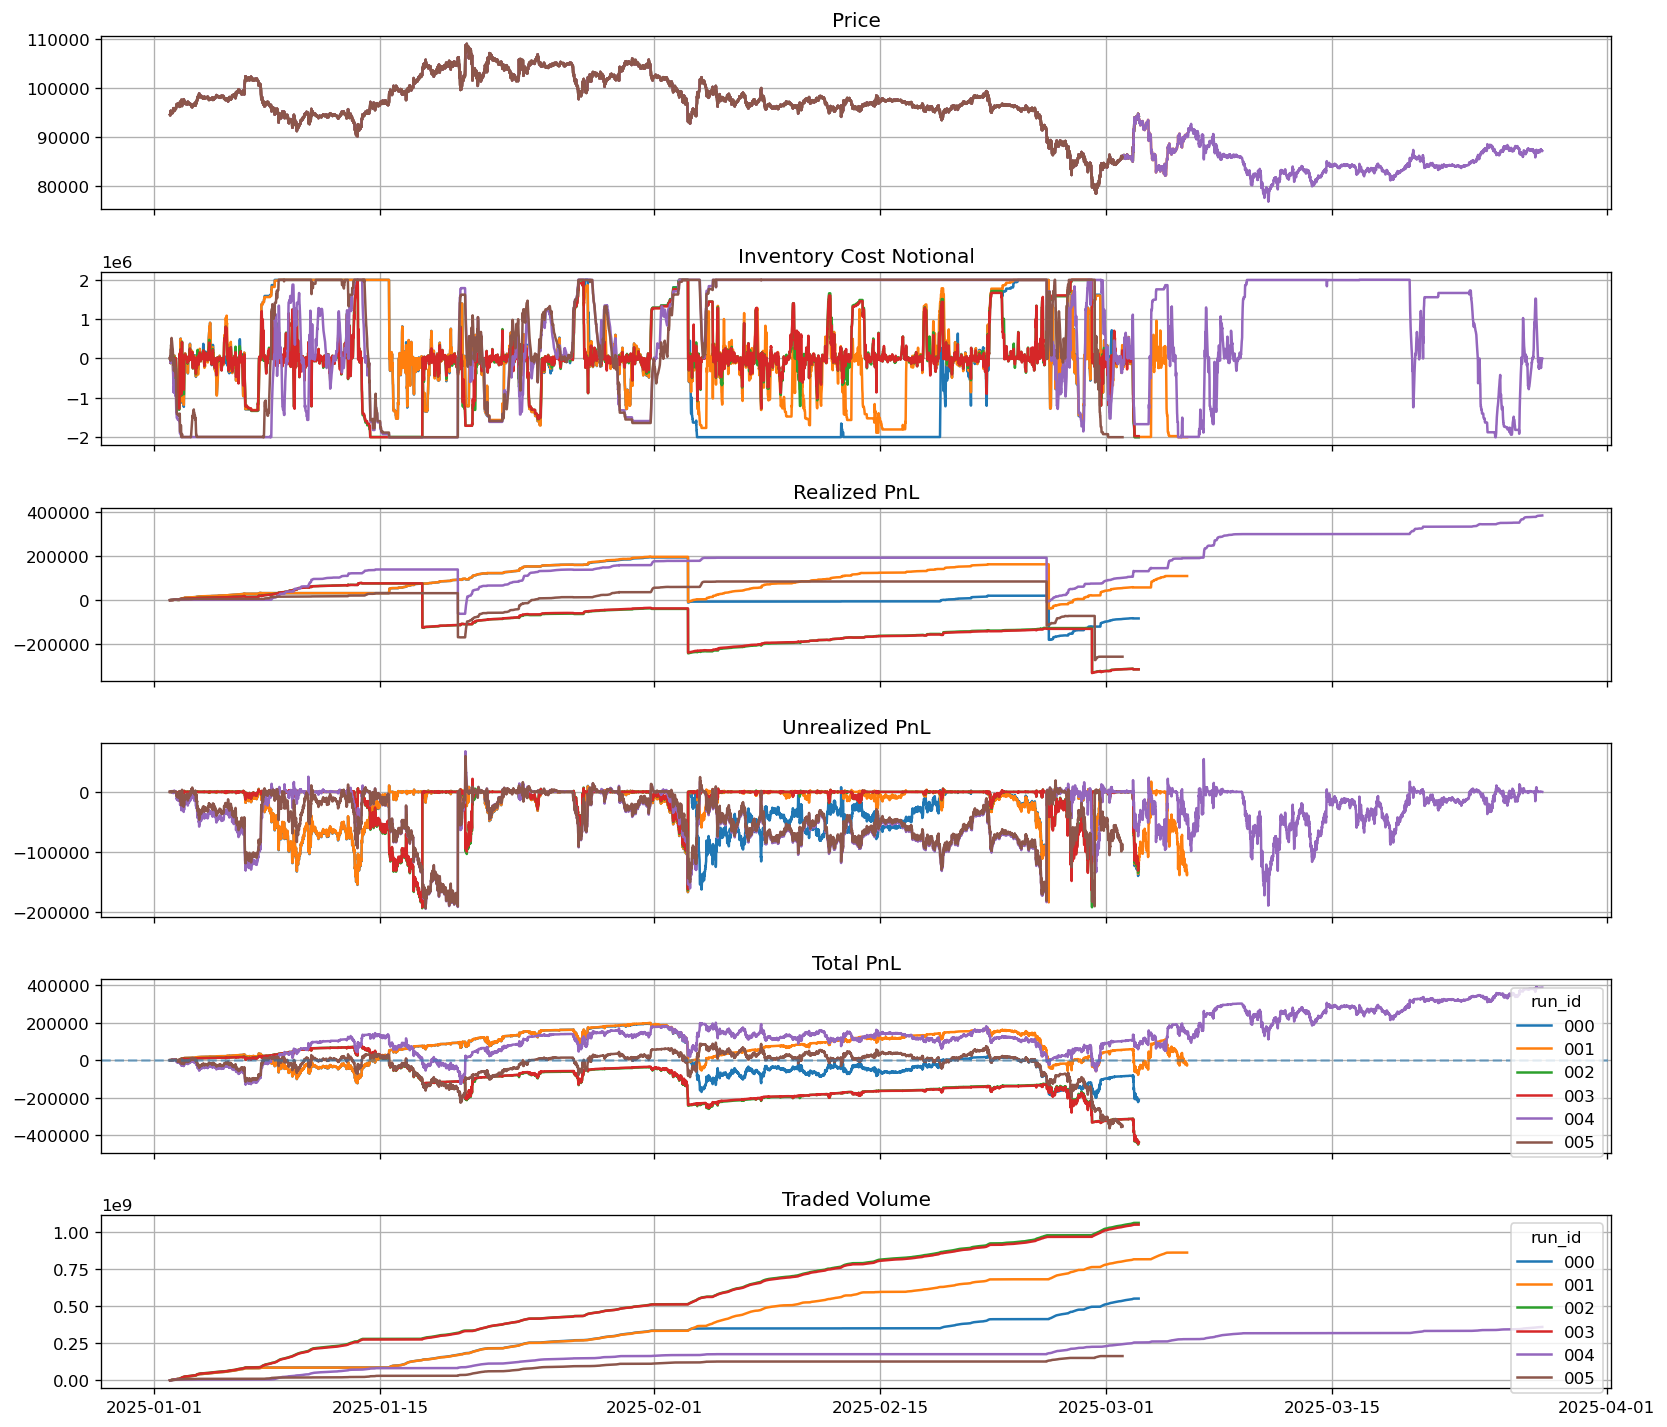

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,000,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...,-210900.369243,-0.079859,-3.429742,401592.485963,-1.377359e+06,-3.429742,-0.079859,8.928134e+06,-0.000382
1,001,63,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...,-24877.287708,-0.013942,-0.833023,259881.721106,-2.164876e+05,-0.833023,-0.013942,1.349357e+07,-0.000029
2,002,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...,-437037.456559,-0.229792,-5.430048,506522.057693,-2.750439e+06,-5.430048,-0.229792,1.752741e+07,-0.000412
3,003,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp...,-434064.242281,-0.231553,-5.428084,503076.693828,-2.730742e+06,-5.428084,-0.231553,1.733228e+07,-0.000413
4,004,85,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,345316.932002,0.095835,6.705723,231137.157837,1.549942e+06,6.705723,0.095835,4.204891e+06,0.000949
5,005,59,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,-352803.330536,-0.128090,-5.018943,435799.181408,-2.187251e+06,-5.018943,-0.128090,2.681203e+06,-0.002147


batch 2: run_id 006..011


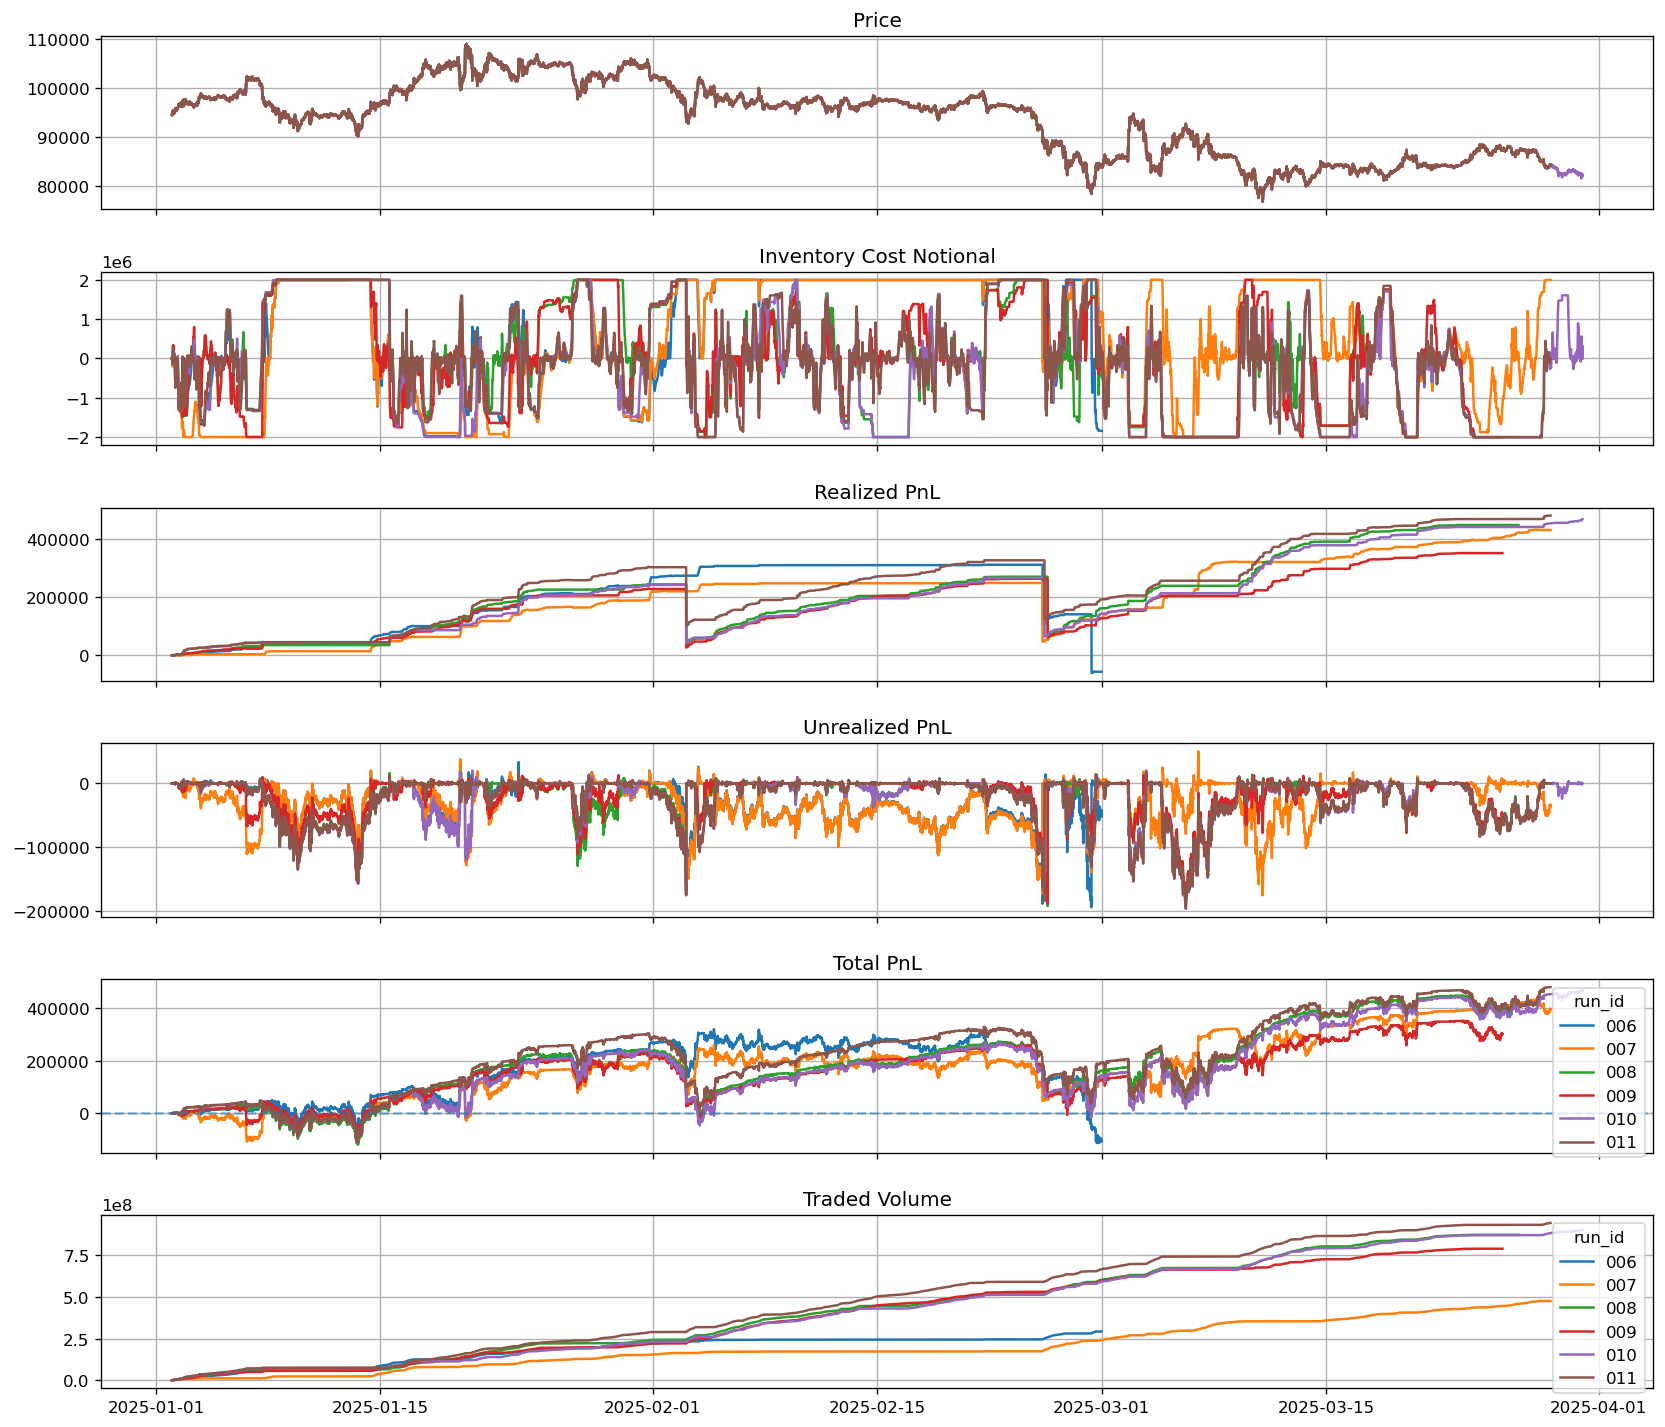

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,006,58,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,-104148.698858,-0.047944,-1.714303,408966.437105,-7.010924e+05,-1.714303,-0.047944,4.905455e+06,-0.000355
1,007,86,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,397304.971434,0.118160,9.952026,173932.212199,1.730978e+06,9.952026,0.118160,5.481628e+06,0.000835
2,008,84,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2...,407512.998165,0.122637,7.416720,237664.735973,1.762693e+06,7.416720,0.122637,1.033452e+07,0.000467
3,009,83,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2...,303418.377857,0.087258,5.691112,232184.156901,1.321386e+06,5.691112,0.087258,9.449267e+06,0.000385
4,010,88,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,468843.321560,0.113664,7.123183,263013.510255,1.873493e+06,7.123183,0.113664,1.010208e+07,0.000520
5,011,85,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,481740.715490,0.119728,7.451812,264777.396085,1.973071e+06,7.451812,0.119728,1.083752e+07,0.000510


batch 3: run_id 012..017


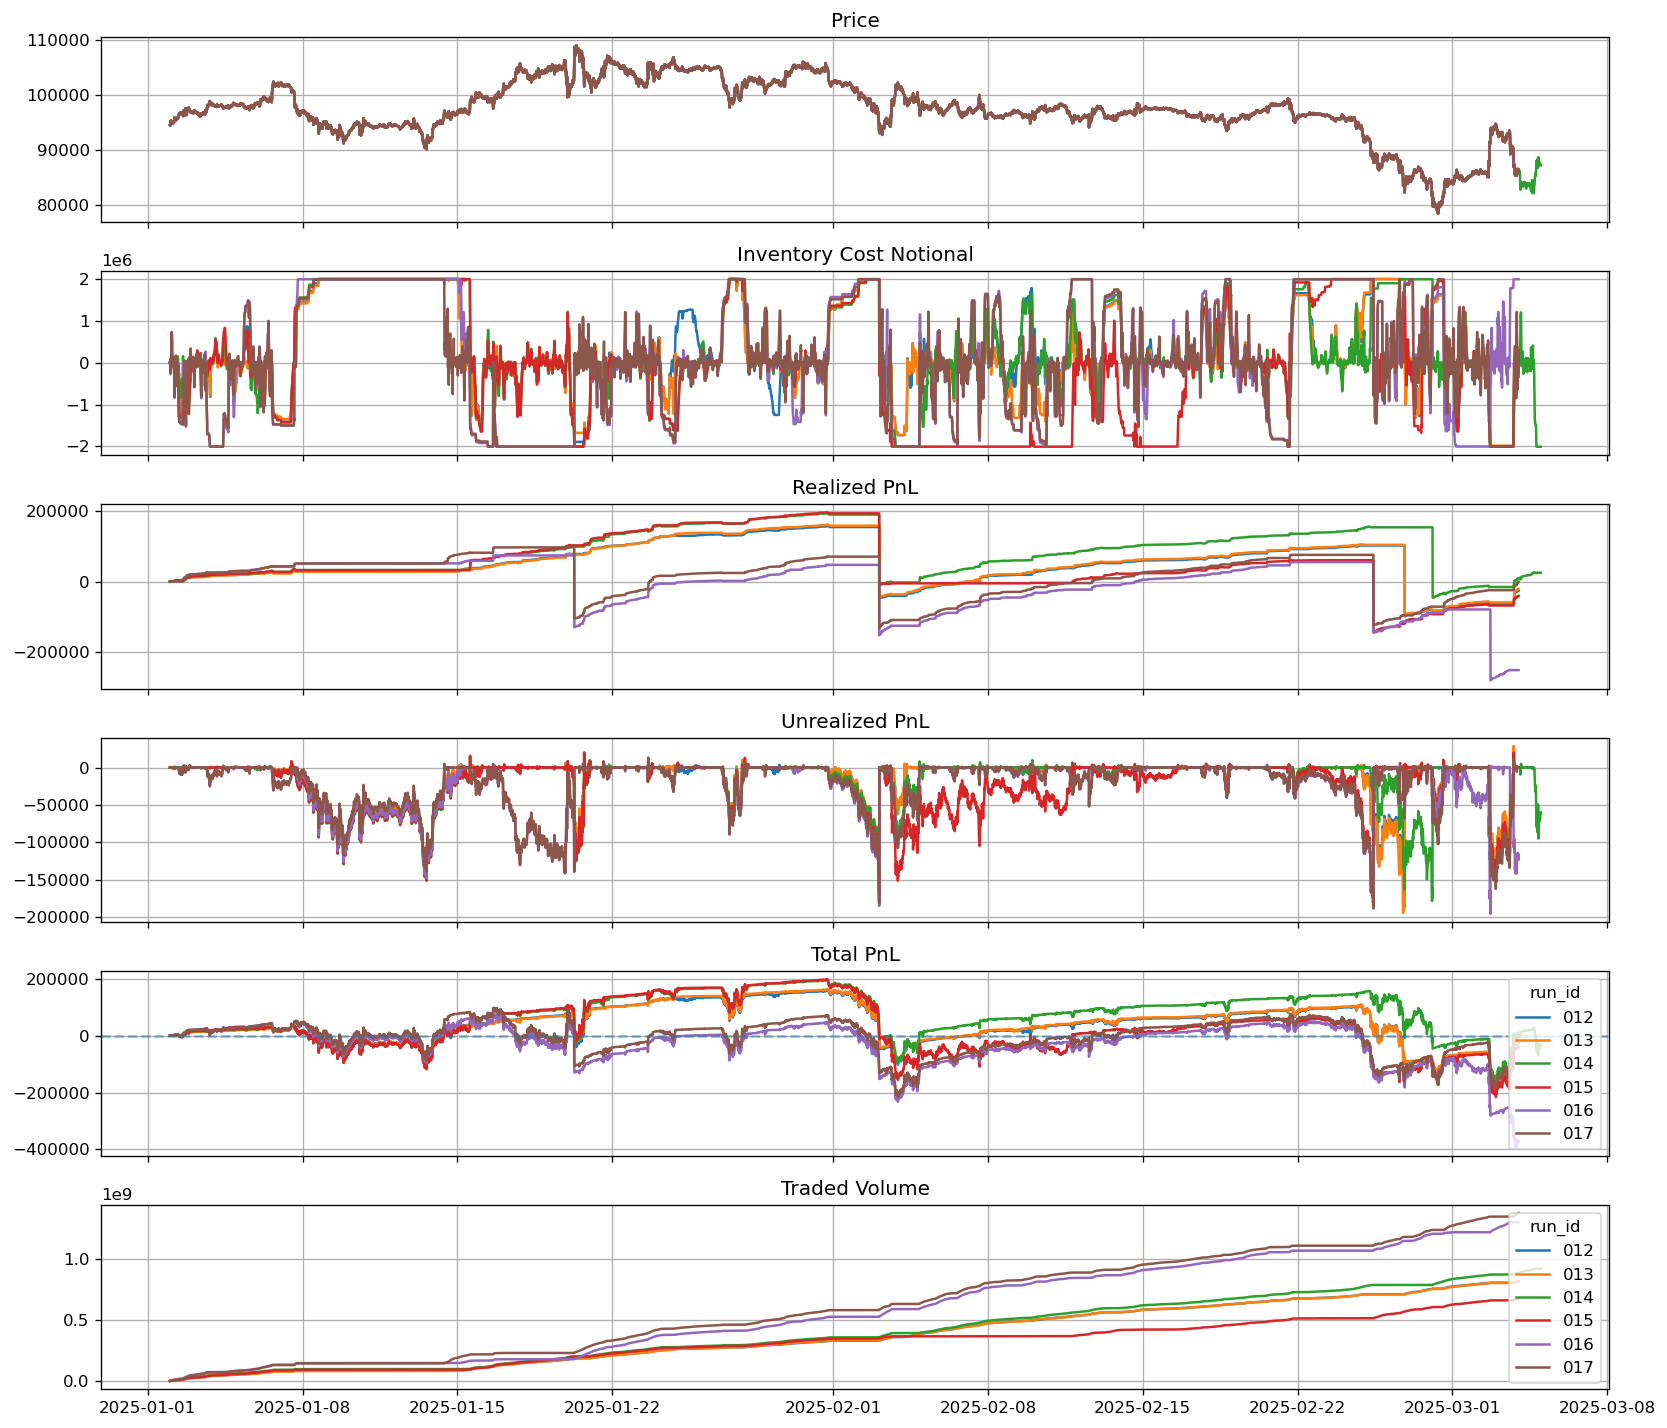

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,012,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2...,-25955.801092,-0.015633,-0.694691,341094.506869,-2.369552e+05,-0.694691,-0.015633,1.323859e+07,-3.171245e-05
1,013,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2...,-21273.959965,-0.013655,-0.605245,337564.634870,-2.043092e+05,-0.605245,-0.013655,1.320023e+07,-2.607698e-05
2,014,62,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,-34443.453988,-0.017971,-0.855960,343962.024843,-2.944177e+05,-0.855960,-0.017971,1.464894e+07,-3.728801e-05
3,015,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,-40377.410316,-0.018875,-0.859508,397290.619429,-3.414744e+05,-0.859508,-0.018875,1.081911e+07,-5.976205e-05
4,016,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-374247.020338,-0.138228,-5.505319,436389.416877,-2.402463e+06,-5.505319,-0.138228,2.093639e+07,-2.870590e-04
5,017,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-60.585175,-0.006447,-0.434136,283057.447501,-1.228853e+05,-0.434136,-0.006447,2.224391e+07,-4.388512e-08


batch 4: run_id 018..023


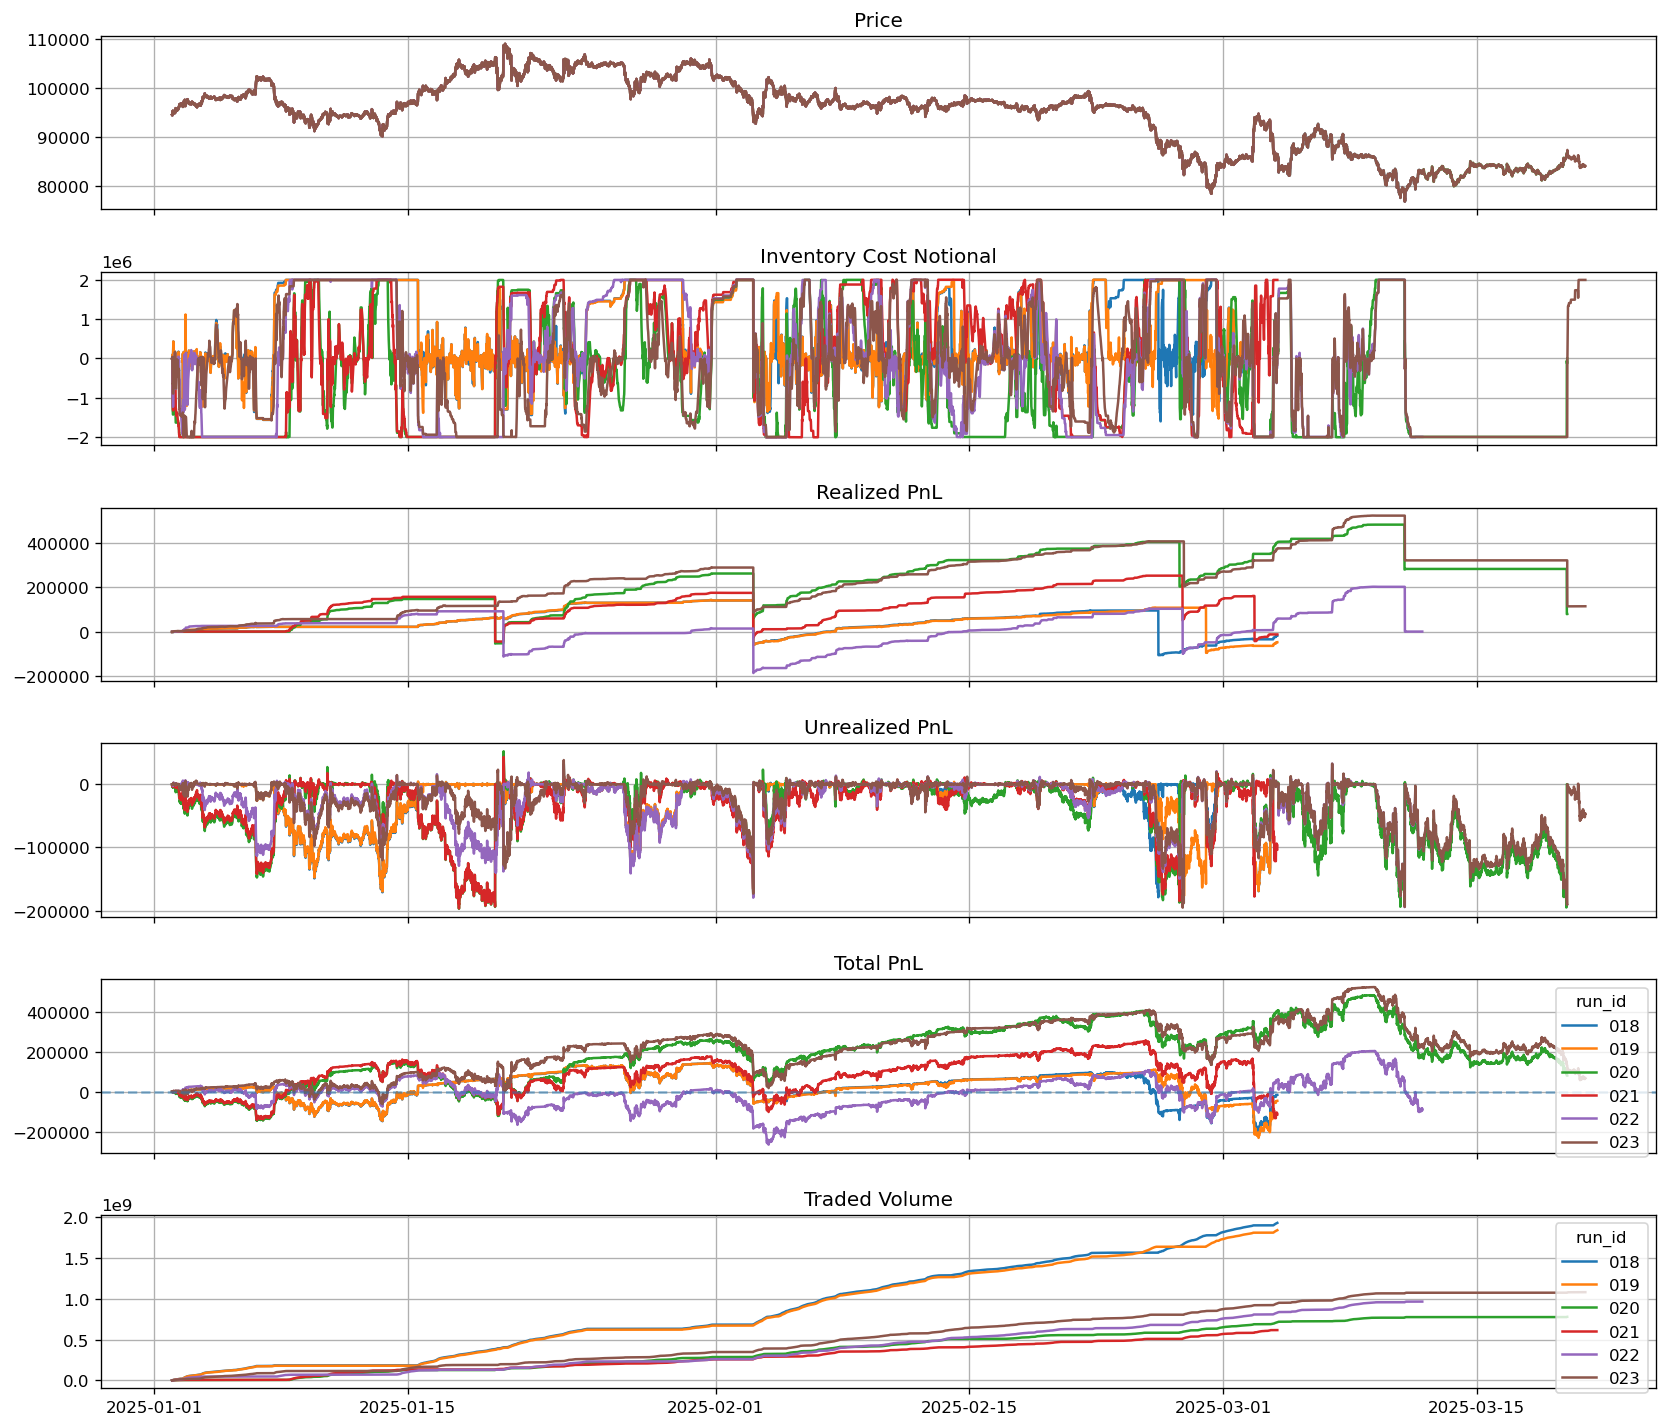

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,018,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-16322.377904,-0.009671,-0.450220,329323.003040,-148267.739257,-0.450220,-0.009671,3.124509e+07,-0.000008
1,019,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-46198.467045,-0.022473,-0.939050,358503.624591,-336652.919683,-0.939050,-0.022473,2.976376e+07,-0.000025
2,020,77,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,80260.487108,0.027448,1.347518,401978.576004,541673.473179,1.347518,0.027448,1.019038e+07,0.000103
3,021,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,-114330.806573,-0.028710,-1.515492,353618.135036,-535905.429063,-1.515492,-0.028710,1.017510e+07,-0.000185
4,022,69,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,-91709.244889,-0.028406,-1.898629,327934.974955,-622626.829344,-1.898629,-0.028406,1.371034e+07,-0.000095
5,023,78,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,68244.606426,0.016276,0.682005,454057.130753,309669.362275,0.682005,0.016276,1.381090e+07,0.000063


batch 5: run_id 024..029


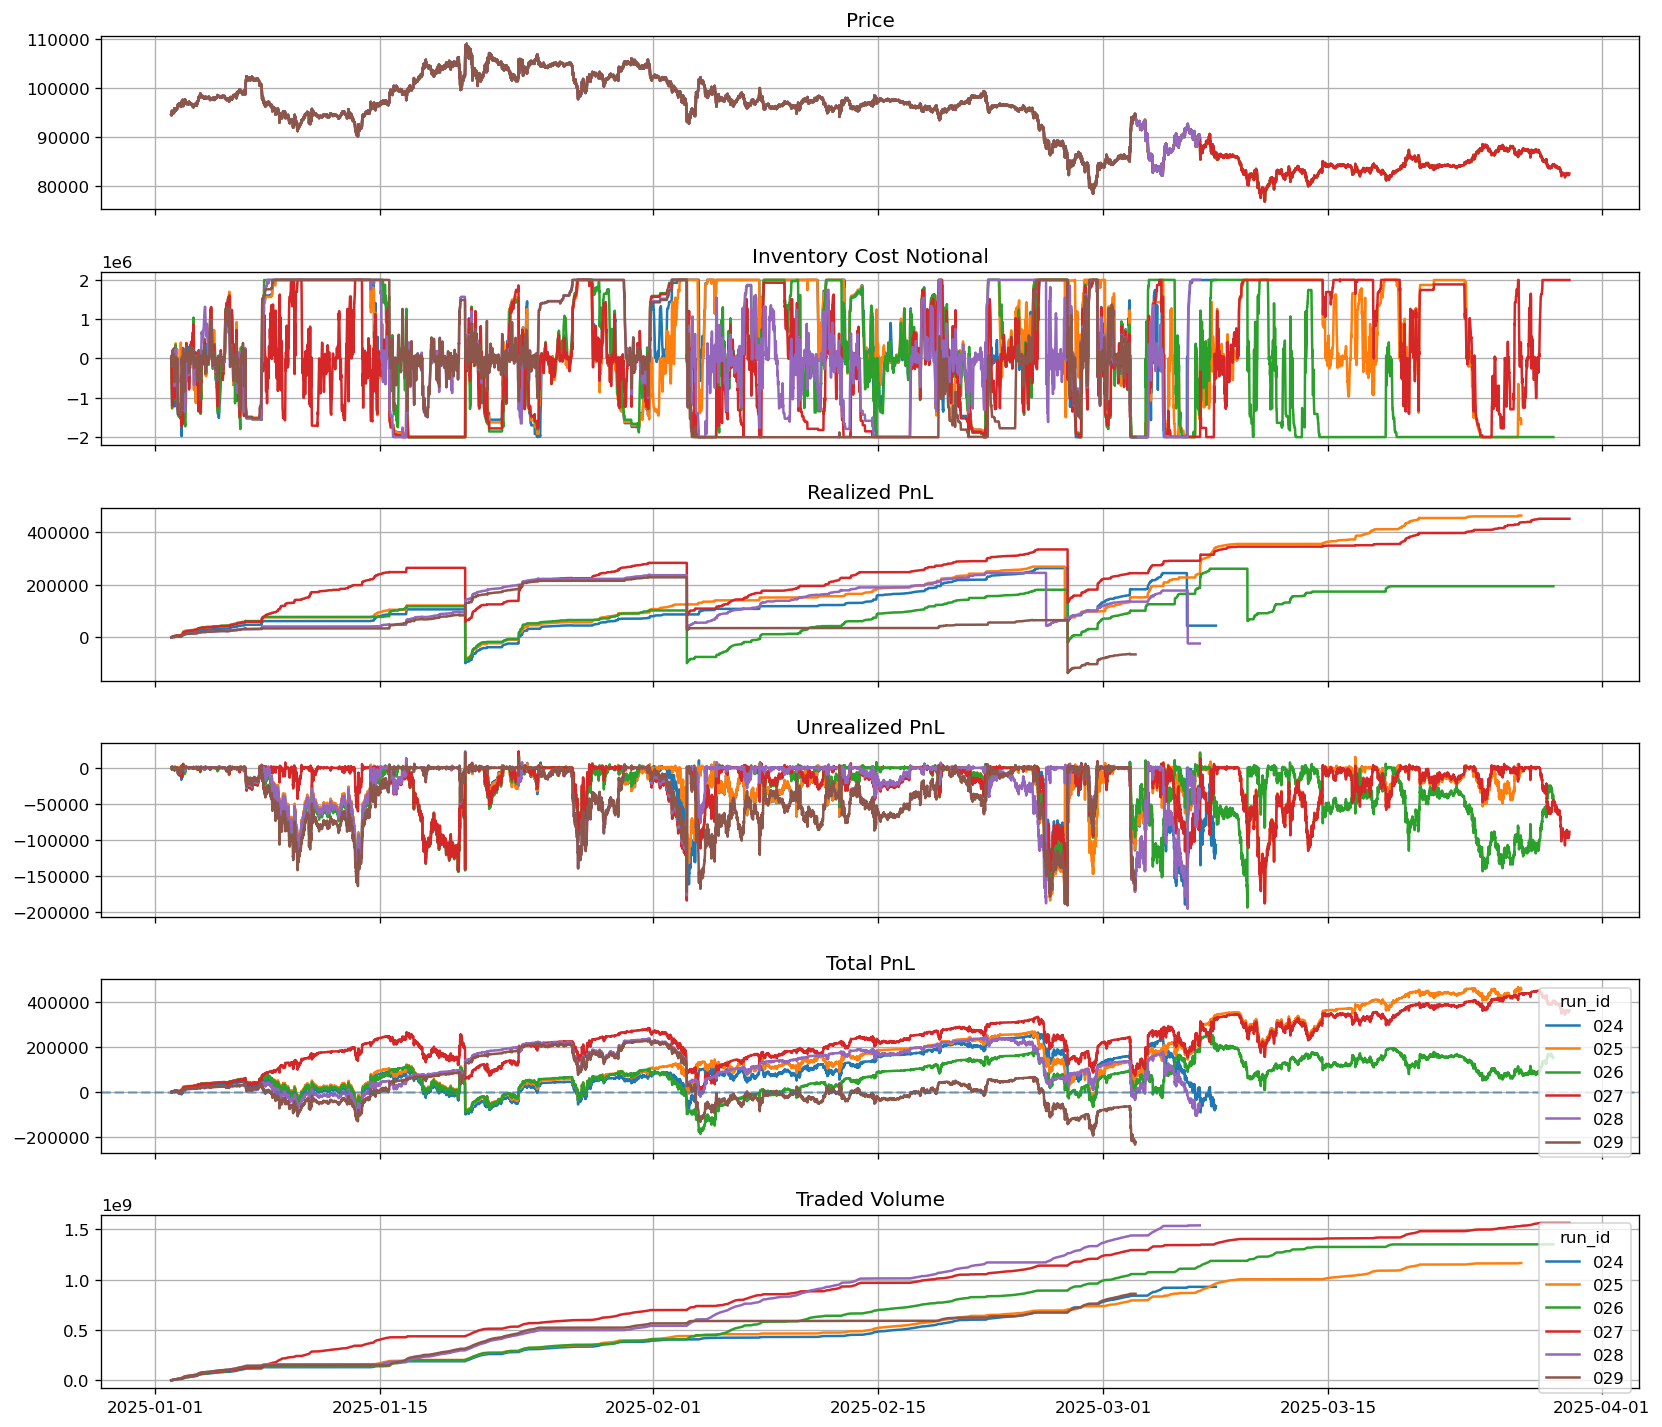

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,024,65,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-62382.744508,-0.027881,-1.465563,304453.226745,-4.461953e+05,-1.465563,-0.027881,1.402316e+07,-0.000067
1,025,83,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,457686.047171,0.121769,8.824534,214916.145280,1.896535e+06,8.824534,0.121769,1.349271e+07,0.000393
2,026,86,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,213240.066247,0.048297,2.979813,269933.110703,8.043502e+05,2.979813,0.048297,1.553738e+07,0.000156
3,027,86,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,362537.495200,0.076704,5.610107,256526.731432,1.439142e+06,5.610107,0.076704,1.775900e+07,0.000232
4,028,64,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-65408.261149,-0.024929,-1.520196,302156.755859,-4.593374e+05,-1.520196,-0.024929,2.374825e+07,-0.000043
5,029,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-221280.609098,-0.079095,-3.256862,445265.369912,-1.450168e+06,-3.256862,-0.079095,1.383861e+07,-0.000257


batch 6: run_id 030..035


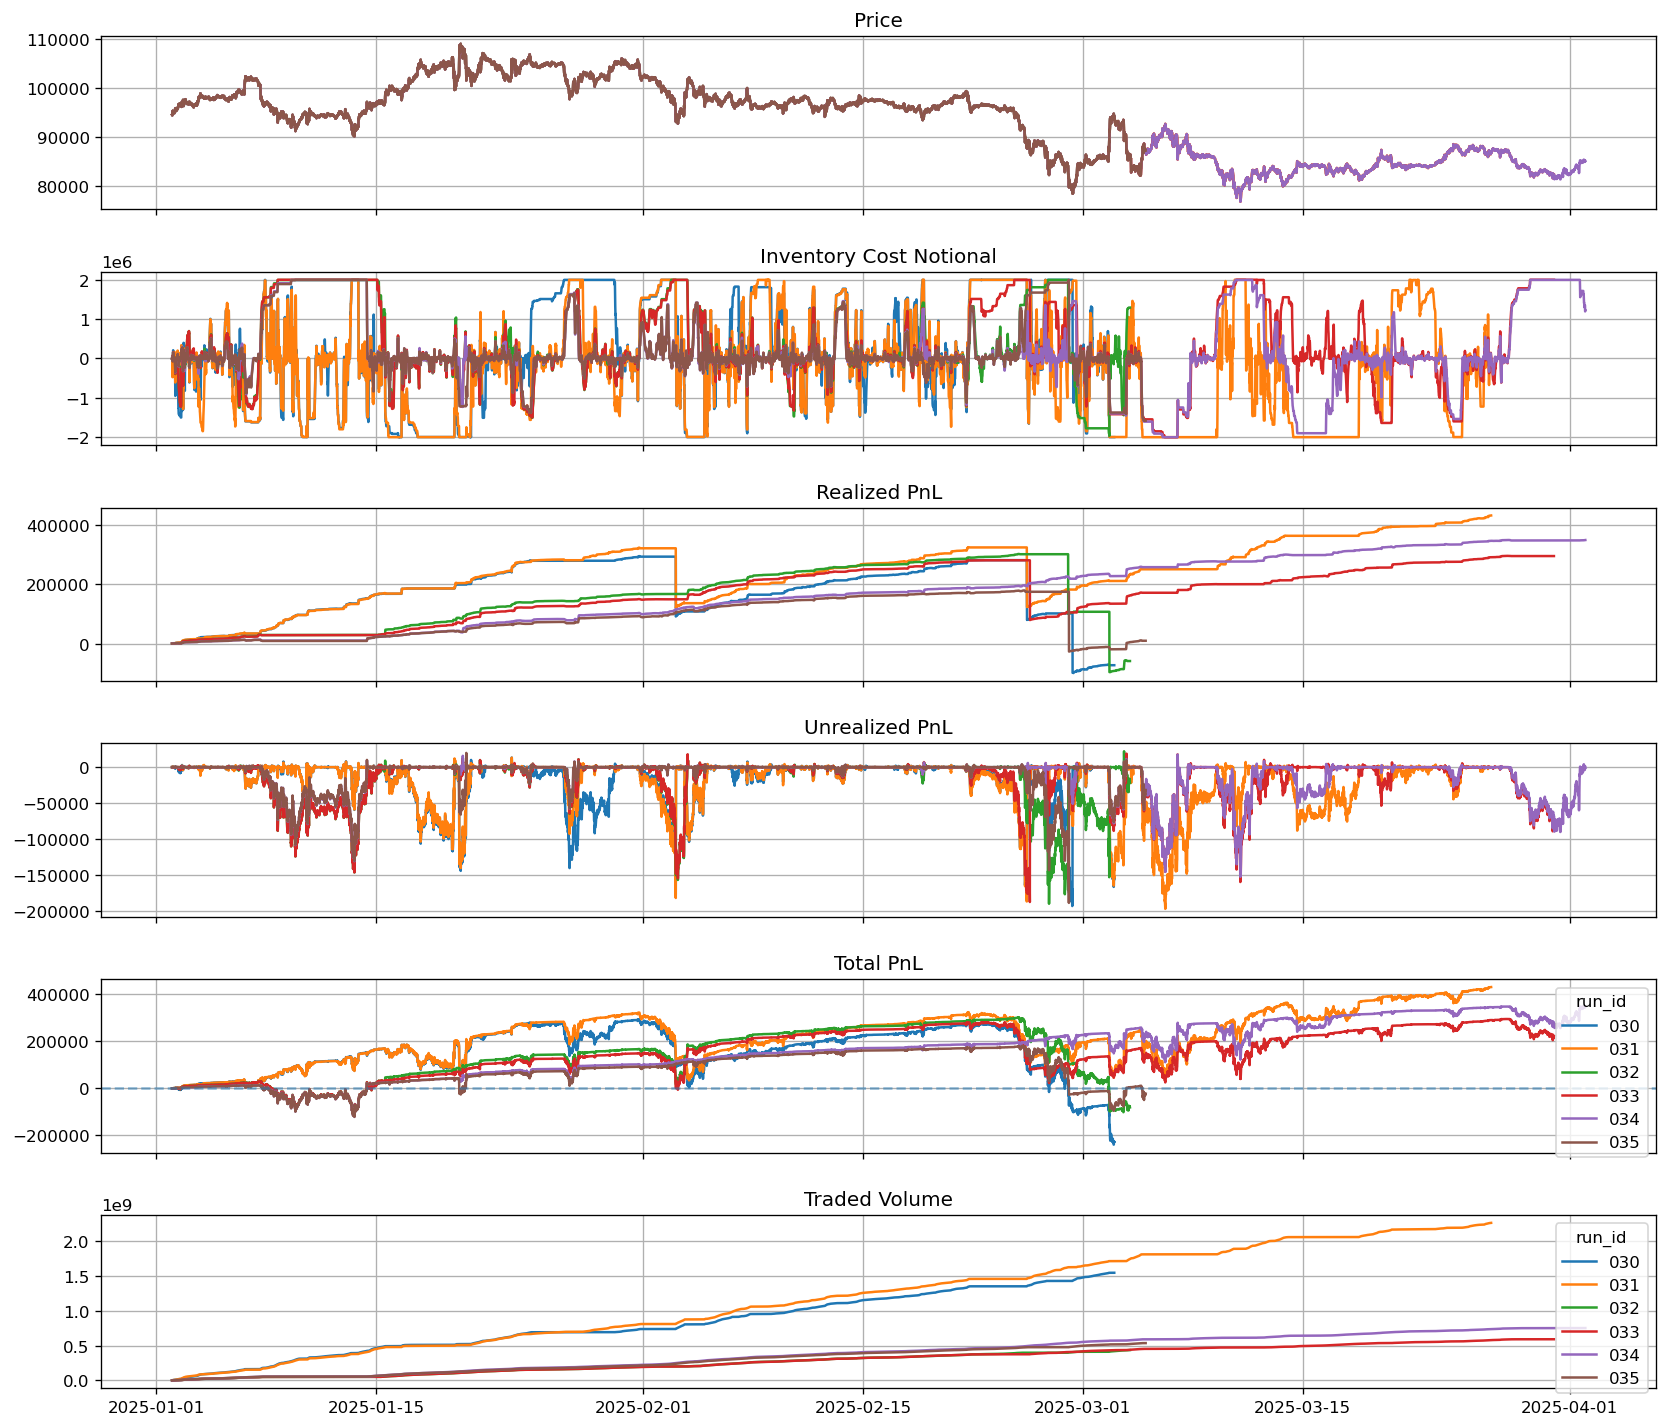

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,030,60,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,-227237.369407,-0.085850,-2.884660,514674.341290,-1.484660e+06,-2.884660,-0.085850,2.534868e+07,-0.000147
1,031,83,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,431524.830624,0.110641,6.988307,263005.571419,1.837964e+06,6.988307,0.110641,2.653979e+07,0.000191
2,032,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-80787.286418,-0.049390,-1.418055,386457.861124,-5.480183e+05,-1.418055,-0.049390,7.030869e+06,-0.000186
3,033,87,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x100__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,222560.067673,0.071304,3.982866,224922.103955,8.958346e+05,3.982866,0.071304,6.637776e+06,0.000377
4,034,89,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,347674.928941,0.139913,12.453340,112983.384455,1.407020e+06,12.453340,0.139913,8.286746e+06,0.000463
5,035,62,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,-22279.369157,-0.016778,-0.615704,262215.861344,-1.614474e+05,-0.615704,-0.016778,8.558433e+06,-0.000042


batch 7: run_id 036..041


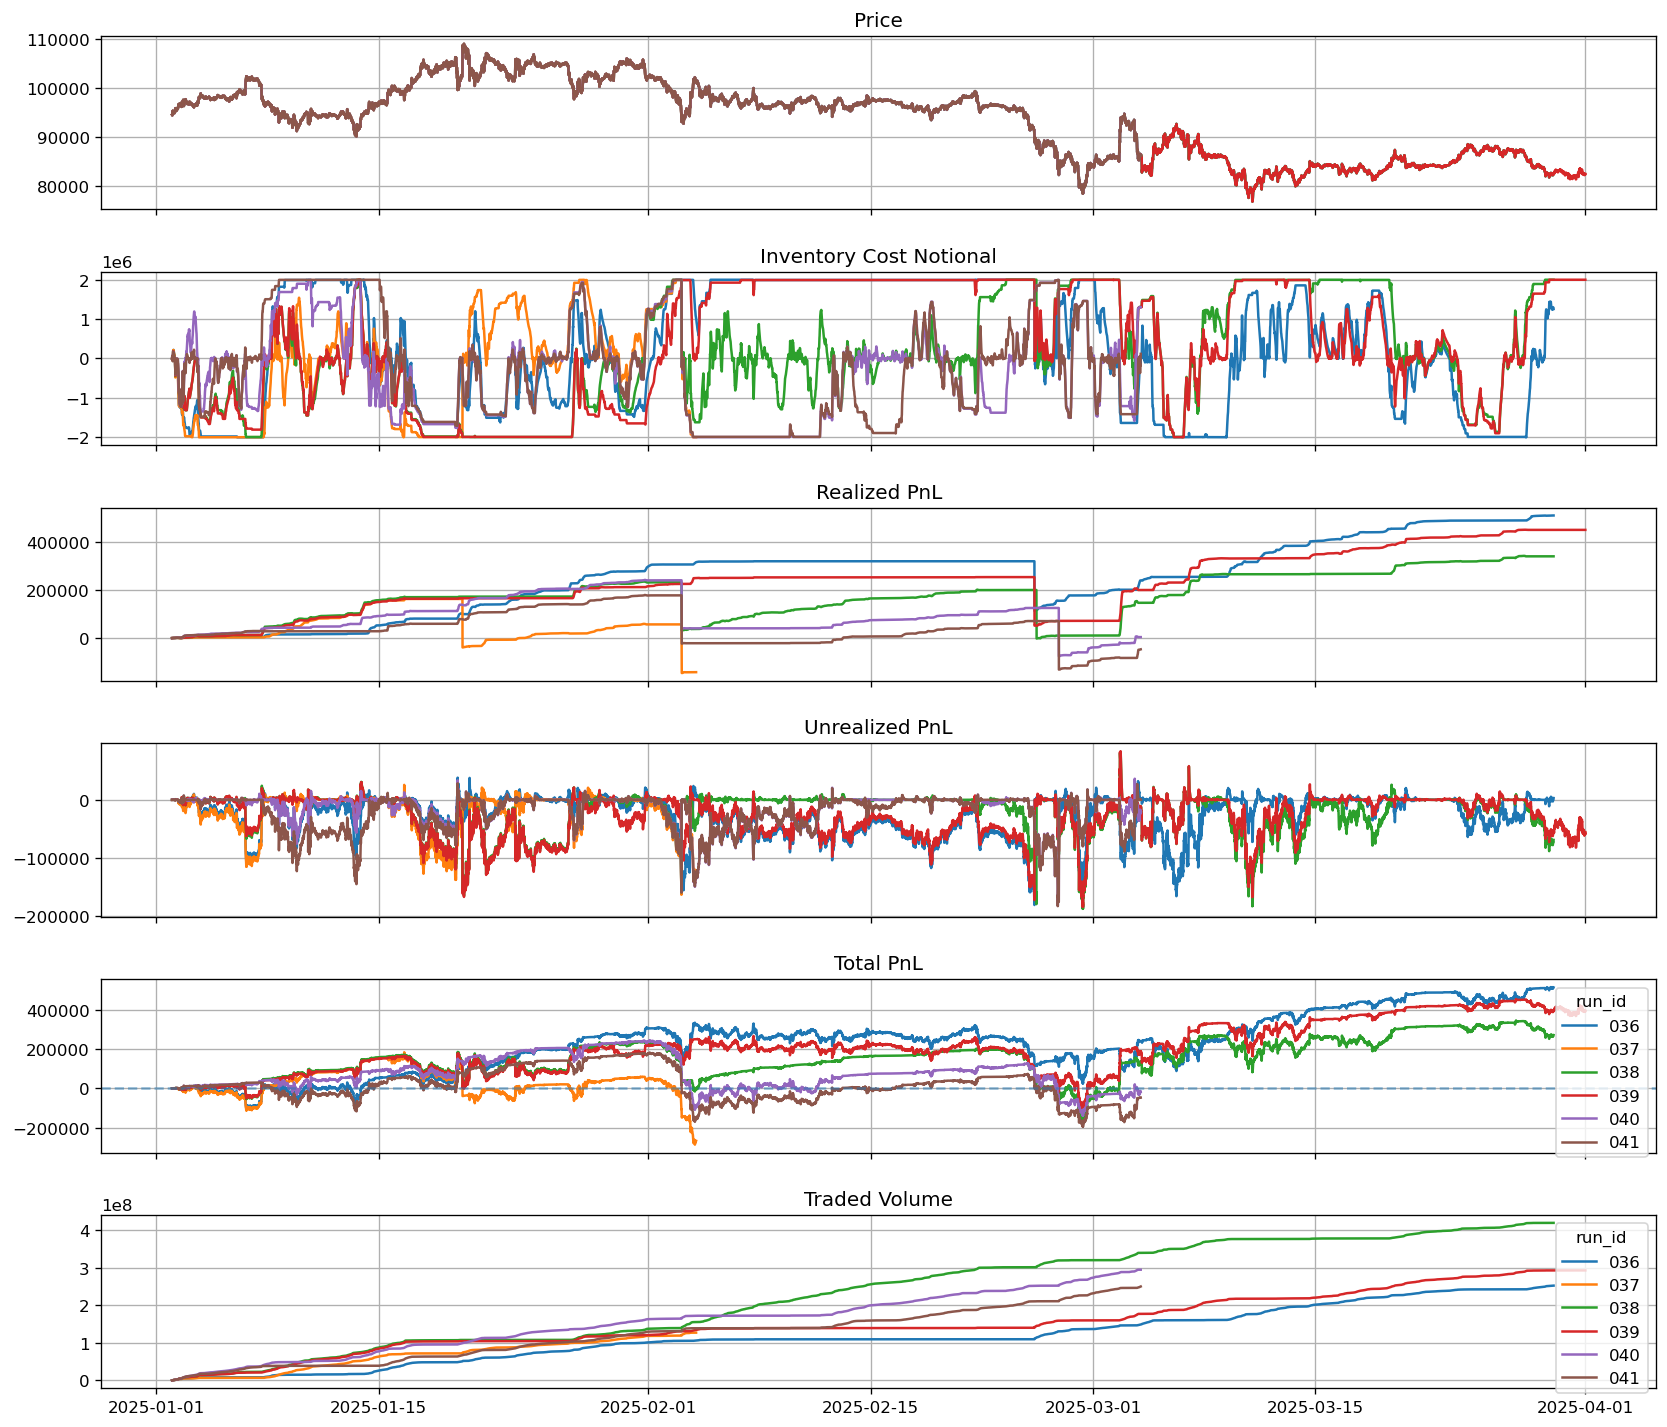

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,036,86,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,512333.856098,0.153204,9.622145,227176.797373,2.185928e+06,9.622145,0.153204,2.871574e+06,0.002028
1,037,33,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,-265975.729597,-0.125139,-7.069135,420090.460675,-2.969676e+06,-7.069135,-0.125139,3.813295e+06,-0.002089
2,038,86,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,270745.843902,0.070074,4.120741,275389.658481,1.134810e+06,4.120741,0.070074,4.776117e+06,0.000645
3,039,88,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,394090.827905,0.116659,7.107764,227956.927701,1.620264e+06,7.107764,0.116659,3.229895e+06,0.001344
4,040,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-18782.880606,-0.011095,-0.549237,328851.003675,-1.806173e+05,-0.549237,-0.011095,4.729123e+06,-0.000064
5,041,61,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,-46479.347072,-0.020242,-1.037330,339783.327132,-3.524673e+05,-1.037330,-0.020242,3.984836e+06,-0.000186


batch 8: run_id 042..047


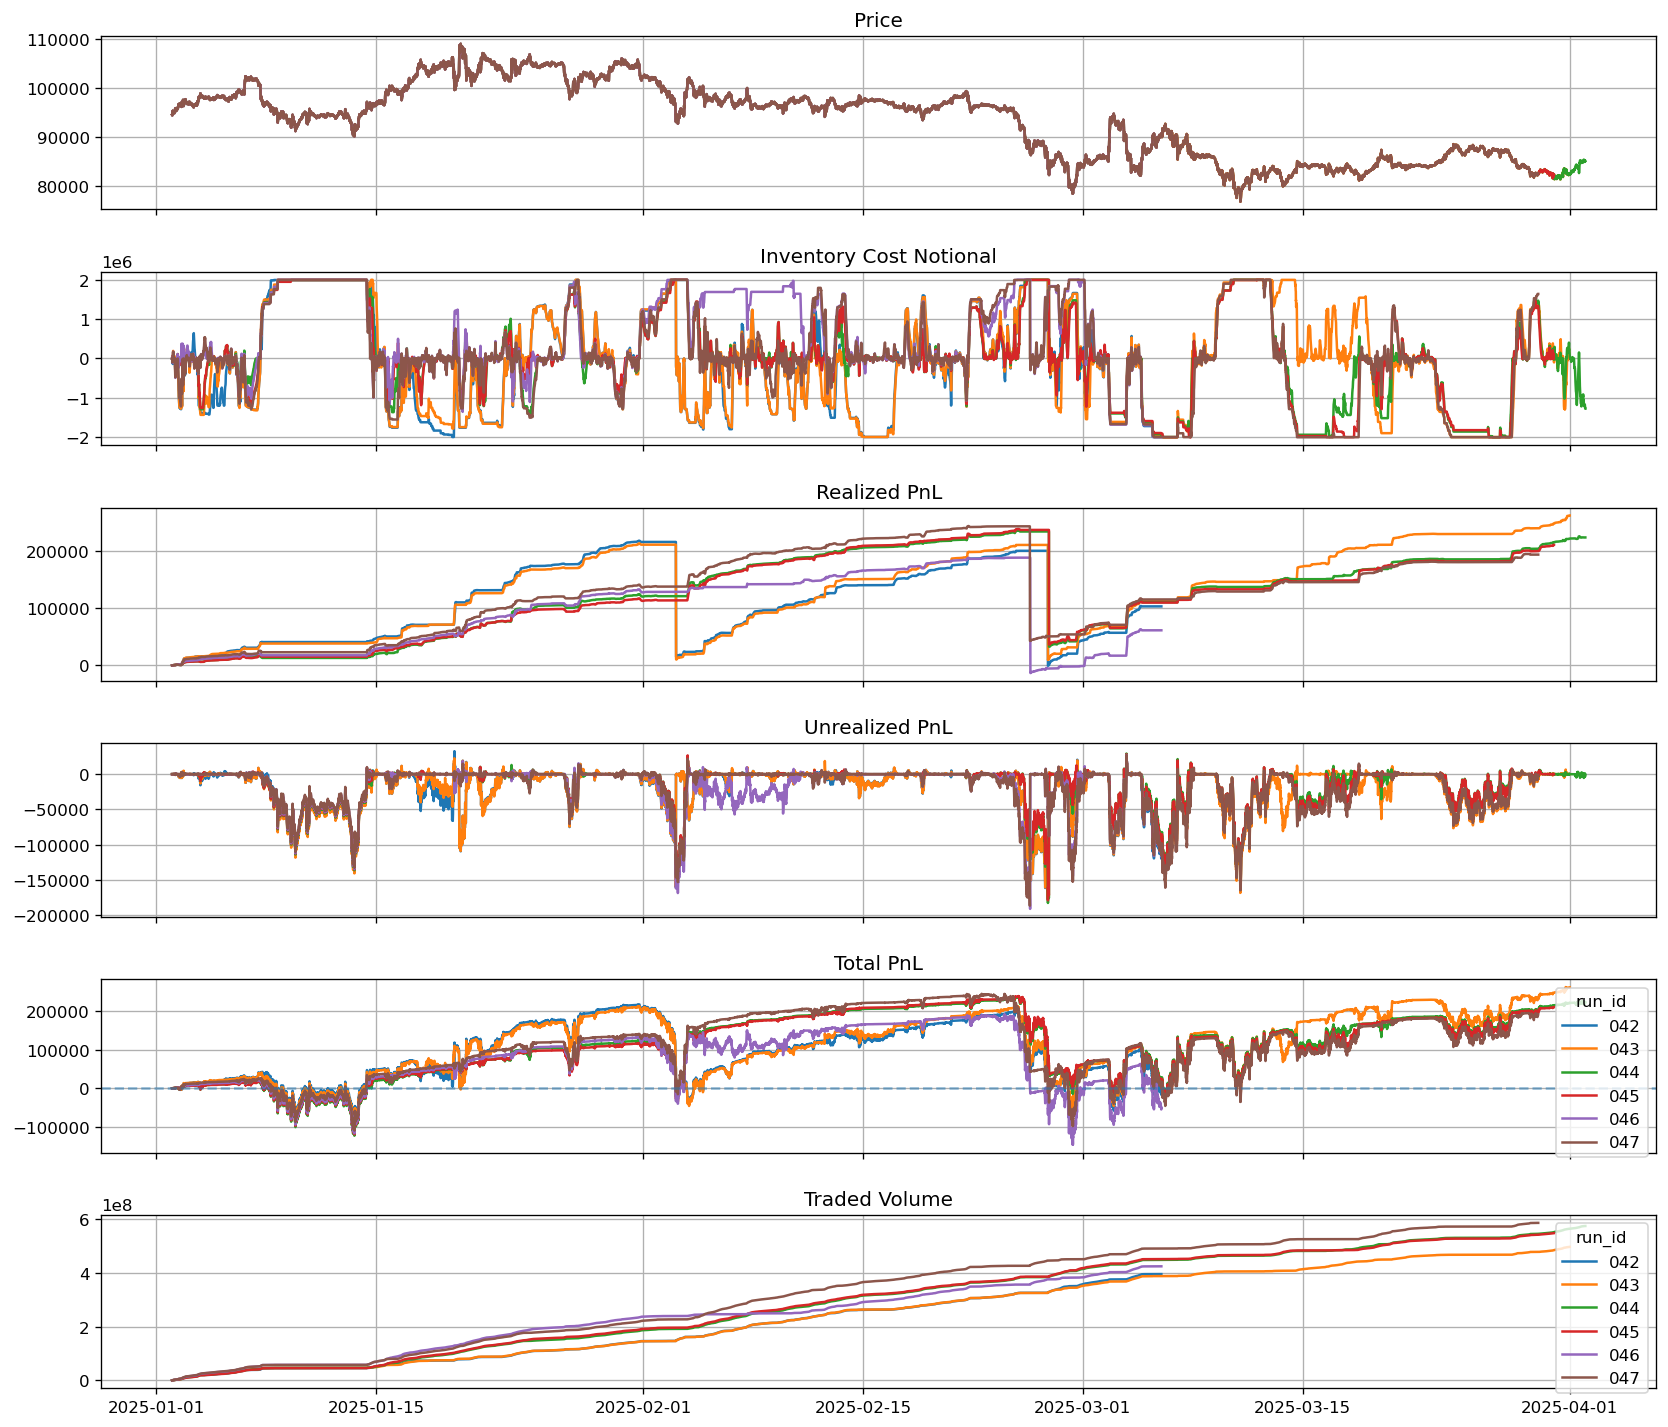

,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,042,63,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,-12402.143738,-0.009920,-0.579321,262854.608274,-1.522773e+05,-0.579321,-0.009920,6.157883e+06,-0.000031
1,043,88,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,262358.418764,0.067061,4.212459,244747.105839,1.030987e+06,4.212459,0.067061,5.490394e+06,0.000528
2,044,89,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,223165.340431,0.072654,3.779187,235135.621999,8.886216e+05,3.779187,0.072654,6.319413e+06,0.000389
3,045,87,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,210727.113112,0.069188,3.625301,236573.012178,8.576483e+05,3.625301,0.069188,6.166322e+06,0.000385
4,046,63,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,-50757.584823,-0.025990,-1.269624,273382.083516,-3.470925e+05,-1.269624,-0.025990,6.604551e+06,-0.000120
5,047,86,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,192855.511268,0.056043,2.817531,273109.276643,7.694939e+05,2.817531,0.056043,6.628241e+06,0.000329


,run_id,file_count,folder,pnls,sharpes,calmars,max_drawdown,annual_return,calmar,sharpe,daily_turnover,spnl
0,036,86,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x20__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,512333.856098,0.153204,9.622145,227176.797373,2.185928e+06,9.622145,0.153204,2.871574e+06,2.028001e-03
1,011,85,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,481740.715490,0.119728,7.451812,264777.396085,1.973071e+06,7.451812,0.119728,1.083752e+07,5.104134e-04
2,010,88,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,468843.321560,0.113664,7.123183,263013.510255,1.873493e+06,7.123183,0.113664,1.010208e+07,5.197330e-04
3,025,83,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp20000...,457686.047171,0.121769,8.824534,214916.145280,1.896535e+06,8.824534,0.121769,1.349271e+07,3.929439e-04
4,031,83,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,431524.830624,0.110641,6.988307,263005.571419,1.837964e+06,6.988307,0.110641,2.653979e+07,1.910216e-04
5,008,84,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2...,407512.998165,0.122637,7.416720,237664.735973,1.762693e+06,7.416720,0.122637,1.033452e+07,4.672448e-04
6,007,86,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1p5x1p5__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000...,397304.971434,0.118160,9.952026,173932.212199,1.730978e+06,9.952026,0.118160,5.481628e+06,8.346695e-04
7,039,88,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x20__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,394090.827905,0.116659,7.107764,227956.927701,1.620264e+06,7.107764,0.116659,3.229895e+06,1.344297e-03
8,027,86,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x10__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000_...,362537.495200,0.076704,5.610107,256526.731432,1.439142e+06,5.610107,0.076704,1.775900e+07,2.318430e-04
9,034,89,/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000...,347674.928941,0.139913,12.453340,112983.384455,1.407020e+06,12.453340,0.139913,8.286746e+06,4.628181e-04


In [26]:
plot_df = choose_folders(limit=MAX_FOLDERS)
all_metrics = []

for start in range(0, len(plot_df), BATCH_SIZE):
    batch = plot_df.iloc[start : start + BATCH_SIZE]
    first_id = int(batch["run_id"].iloc[0])
    last_id = int(batch["run_id"].iloc[-1])
    print(f"batch {start // BATCH_SIZE + 1}: run_id {first_id:03d}..{last_id:03d}")
    all_metrics.append(plot_folder_batch(batch))

summary_df = pd.concat(all_metrics, ignore_index=True) if all_metrics else pd.DataFrame()
display(summary_df.sort_values("pnls", ascending=False).reset_index(drop=True))

In [27]:
folders[31]

'/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi1x1__asv0x0__bpc1__bp0x50__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi300__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__ink__oc1x1x1__obom1__po1__pcp1200000__phmmarket__pp1__qp3__sm1__sl200__h3bba14956b/strat__all'

In [28]:
folders[35]

'/data/users/kang/backtest/glftmm/result/BTCUSDT/sim__asir0__asi2x2__asv0x0__bpc1__bp0x100__bu50x20__cc1x1x1__fr1000__hs1200000__isk0x1__lat2__lbi12_120__mfm3em05__mhtm1__mp2000000__mon100__moq0__mqdb0p05__md1__inkls__oc1x1x1__obom1__po1__pcp1200000__phmmarket__pp1__qp3__sm1___ha93d50f3ac/strat__all'

Inspect one folder with the full report panels.

Compare selected folders on one PnL chart.